# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int64  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int64  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int64  
 17  month        10886 non-null  int64  
 18  hour       

Оригінальний датасет містить: 10 886 рядків х 12 колонок,  розмір - 1020.7 KB. 

Після підготовки даних: 10 886 рядків × 19 колонок (через datetime: додаткові колонки), розмір 1,4+МВ.

Порожніх значень немає (усе non-Null). Деталізація на рівні рядку - година, видно із datetime. Часовий проміжок: 01.01.2011 - 19.12.2012.

In [6]:
# Сезони Індії за місяцями
# 1 = Winter, 2 = Summer, 3 = Monsoon, 4 = Post-Monsoon

season_num_map_india = {
    12: 1, 1: 1, 2: 1,          # Winter
    3: 2, 4: 2, 5: 2,           # Summer
    6: 3, 7: 3, 8: 3, 9: 3,     # Monsoon
    10: 4, 11: 4                # Post-Monsoon
}

df['weather_season_india'] = df['month'].map(season_num_map_india)

# Текстові назви сезонів
season_name_map_india = {
    1: 'Winter',
    2: 'Summer',
    3: 'Monsoon',
    4: 'Post-Monsoon'
}

df['weather_season_india_name'] = df['weather_season_india'].map(season_name_map_india)

df[['month', 'weather_season_india', 'weather_season_india_name']].head(3)

,month,weather_season_india,weather_season_india_name
datetime,,,
2011-01-01 00:00:00,1,1,Winter
2011-01-01 01:00:00,1,1,Winter
2011-01-01 02:00:00,1,1,Winter


In [7]:
df['weather_season_india_name'].value_counts()

Monsoon         3645
Summer          2722
Winter          2697
Post-Monsoon    1822
Name: weather_season_india_name, dtype: int64

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


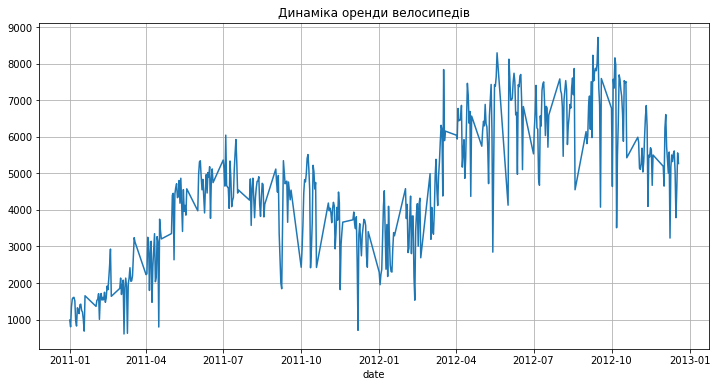

In [8]:
df.groupby('date')['count'].sum().plot(
    figsize=(12, 6),  
    title="Динаміка оренди велосипедів", 
    grid=True
);

1. Динаміка показників: Різкі коливання на графіку зумовлені добовими факторами (погодні умови, тип дня — робочий чи вихідний, святкові дати). Для нівелювання цих "шумів" та чіткішої візуалізації доцільно використовувати метод ковзного середнього (наприклад, за 7-денний період).

2. Порівняльний аналіз: Спостерігається виражена тенденція до зростання попиту в теплий сезон із подальшим спадом у зимові місяці. При цьому показники 2012 року демонструють стабільно вищий рівень порівняно з аналогічним періодом 2011 року.

3. Сезонний фактор: Підтверджено наявність сезонності: пікові значення припадають на середину року, тоді як мінімальна активність фіксується взимку.

4. Аномалії: Виявлено окремі відхилення від загального тренду. Аномально низький або високий попит, імовірно, спричинений погодними форс-мажорами, державними святами або локальними заходами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?

In [9]:
# Середня кількість оренд за сезонами Індії
season_avg = (
    df.groupby(['weather_season_india', 'weather_season_india_name'])['count']
    .mean()
    .reset_index()
    .sort_values('weather_season_india')
)

season_avg

,weather_season_india,weather_season_india_name,count
0,1,Winter,125.753430
1,2,Summer,184.074210
2,3,Monsoon,236.322359
3,4,Post-Monsoon,210.688255


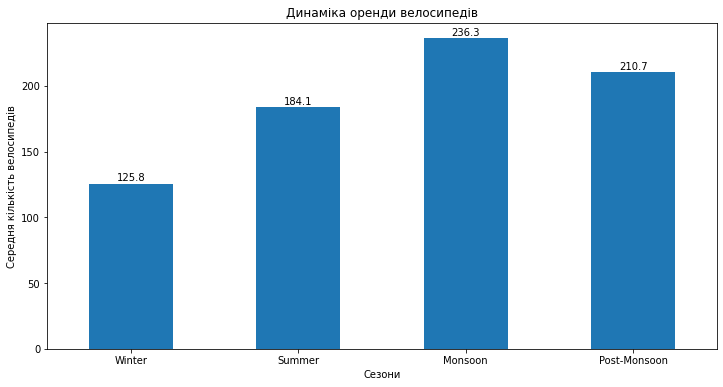

In [10]:
ax = season_avg.plot.bar(
    figsize=(12, 6),  
    title="Динаміка оренди велосипедів", 
    x='weather_season_india_name',
    y='count',
    xlabel='Сезони',
    ylabel='Середня кількість велосипедів',    
    legend=False
)

# Повертаємо підписи осі X горизонтально
plt.xticks(rotation=0)

# Додаємо підписи над стовпчиками
for i, v in enumerate(season_avg['count']):
    ax.text(i, v + 2, f'{v:.1f}', ha='center')

plt.show()

1. Лідируючі показники: Максимальна середня інтенсивність прокату зафіксована у сезоні Monsoon (3), де показник становить приблизно 236 одиниць.

2. Причинно-наслідковий зв'язок: Такий результат зумовлений сприятливими кліматичними умовами та загальним сезонним зростанням попиту, що робить цей період найбільш комфортним для користувачів.

3. Порівняльна характеристика: Найнижча активність спостерігається взимку (Winter, сезон 1). Попит у сезон мусонів перевищує зимові показники майже вдвічі (коефіцієнт 1.88).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


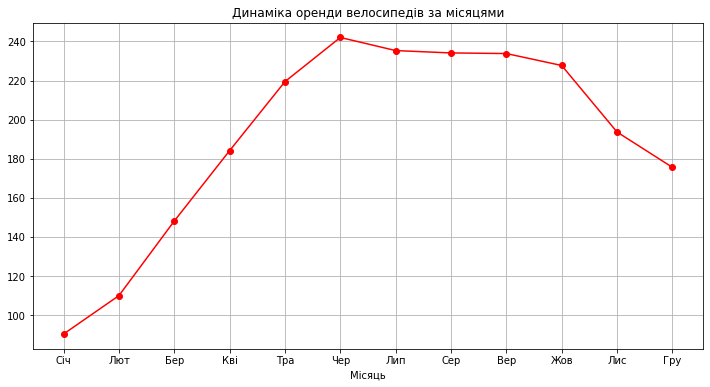

In [11]:
month_avg = df.groupby('month')['count'].mean()

ax = month_avg.plot(
    figsize=(12, 6),  
    title="Динаміка оренди велосипедів за місяцями", 
    grid=True,
    marker='o',
    color='red',
    xlabel='Місяць'
);

# 12 поділок по осі X
ax.set_xticks(range(1,13))

# Підписи місяців 
ax.set_xticklabels( 
    ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру'],
    rotation=0
)

plt.show()

1. Найпопулярнішим місяцем виявився червень, а загалом високий сезон триває з червня по жовтень. Найменш активним місяцем є січень.

2. Графік наочно демонструє ту саму тенденцію, що й раніше: люди активніше орендують велосипеди в теплу пору року.

3. Це підтверджує пряму залежність бізнесу від клімату — комфортна погода автоматично конвертується у більшу кількість замовлень.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

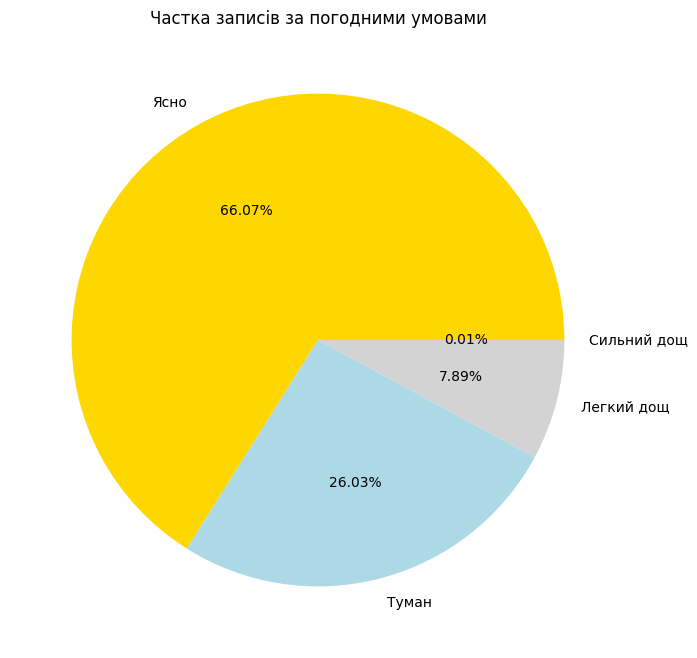

In [12]:
df['weather'].value_counts()

1    7192
2    2834
3     859
4       1
Name: weather, dtype: int64

In [13]:
weather_agr = df['weather'].value_counts().sort_index()

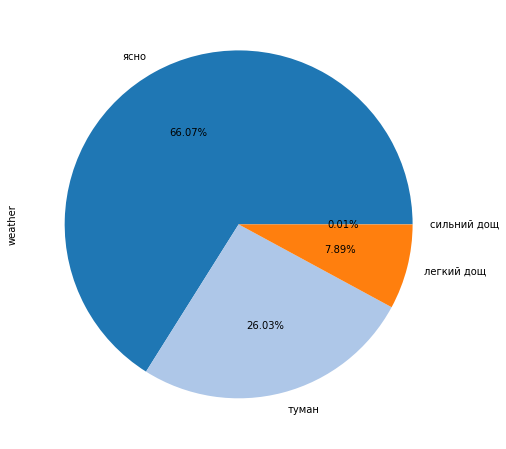

In [14]:
weather_agr.plot.pie(
    figsize=(8,8),
    labels=['ясно', 'туман', 'легкий дощ', 'сильний дощ'],
    colors=plt.cm.tab20.colors,
    autopct='%1.2f%%'
);

1. Переважна погода: Більшість записів (66%) відповідають ясним погодним умовам.

2. Аномальні значення: Сильні зливи трапляються вкрай рідко — лише 1 випадок за весь період дослідження (0.01%).

3. Залежність попиту: Існує зворотний зв'язок між складністю погодних умов та кількістю оренд: туман і дощ стримують користувачів від поїздок.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [15]:
weather_name_map = {
    1: 'ясно',
    2: 'туман',
    3: 'легкий дощ',
    4: 'сильний дощ'
}

df['type_weather'] = df['weather'].map(weather_name_map)

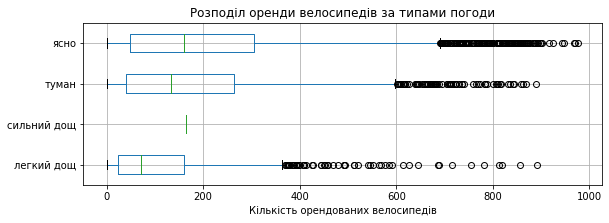

In [16]:
df.boxplot(
    column = 'count',
    by = 'type_weather',
    figsize = (9,3),
    rot = 0,
    vert = False
)
plt.title('Розподіл оренди велосипедів за типами погоди')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('')
plt.show()

1. Розкид: Ясна погода має найбільшу амплітуду значень, що логічно для наймасовішої категорії даних.

2. Аномалії: Викиди зафіксовані для категорій «ясно», «туман» та «легкий дощ». Для «сильного дощу» даних недостатньо для оцінки (лише 1 запис).

3. Лідируюча категорія: Ясна погода демонструє найвищу медіану оренди, що свідчить про стабільно вищий попит у сонячні дні.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

/opt/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


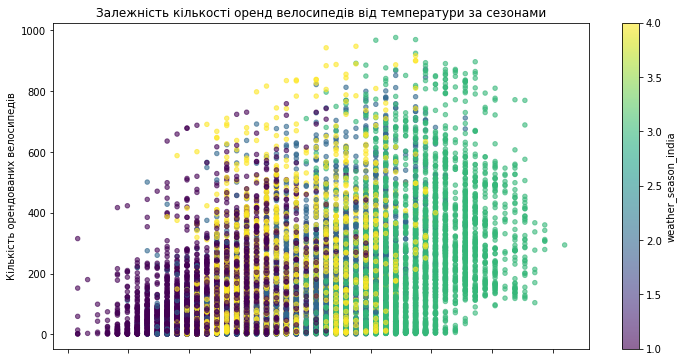

In [17]:
df.plot.scatter(
    x='temp',
    y='count',
    c='weather_season_india',
    colormap='viridis',
    figsize=(12,6),
    title="Залежність кількості оренд велосипедів від температури за сезонами",    
    alpha=0.6,
    xlabel='Температура (°C)',
    ylabel='Кількість орендованих велосипедів'
);

1. Зв’язок: Чим вища температура, тим більше оренд (найнижчі цифри — у 1-му сезоні через холод).

2. Пік: Найбільша популярність сервісу припадає на помірну погоду — від 14°C до 26°C.

3. Аномалія спеки: При температурі 35°C+ попит починає падати. Отже, існує «температурний поріг», після якого кататися стає некомфортно.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

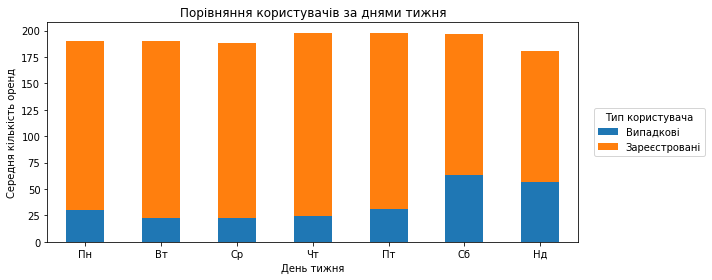

In [18]:
# Середня кількість оренд по днях тижня (0=Monday ... 6=Sunday)
user_comparison = df.groupby('weekday_num')[['casual', 'registered']].mean()

# Побудова stacked bar chart
ax = user_comparison.plot.bar(
    figsize=(10, 4),
    stacked=True,
    color=plt.cm.tab10.colors,
    title='Порівняння користувачів за днями тижня'
)

# Підписи осей
ax.set_xlabel('День тижня')
ax.set_ylabel('Середня кількість оренд')

# Заміна підписів 0..6 на дні тижня (укр)
ax.set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'], rotation=0)

# Легенда справа
ax.legend(['Випадкові', 'Зареєстровані'], title='Тип користувача',
          loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

1. Зареєстровані клієнти: Пік активності — будні дні; у вихідні попит помірно спадає.

2. Причина: Постійні користувачі використовують сервіс як частину щоденної рутини (справи/робота), тоді як разові поїздки мають переважно розважальний характер і зосереджені у вихідні.